In [1]:
import os

# This forces TensorFlow to use the internal Keras 2 instead of the new Keras 3
os.environ['TF_USE_LEGACY_KERAS'] = '1'

# Time series forecasting in TensorFlow (BitPredict 💰📈)

We're going to be building a series of models in an attempt to predict the price of Bitcoin. 


## What is a time series problem?

Time series problems deal with data over time.

Such as, the number of staff members in a company over 10-years, sales of computers for the past 5-years, electricity usage for the past 50-years.

The timeline can be short (seconds/minutes) or long (years/decades). And the problems you might investigate using can usually be broken down into two categories.

![example time series problems](https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/10-example-time-series-problems.png)

| Problem Type | Examples | Output |
| ----- | ----- | ----- |
| **Classification** | Anomaly detection, time series identification (where did this time series come from?) | Discrete (a label) |
| **Forecasting** | Predicting stock market prices, forecasting future demand for a product, stocking inventory requirements | Continuous (a number) |

In both cases above, a supervised learning approach is often used. Meaning, you'd have some example data and a label assosciated with that data.

For example, in forecasting the price of Bitcoin, your data could be the historical price of Bitcoin for the past month and the label could be today's price (the label can't be tomorrow's price because that's what we'd want to predict).


## What we're going to cover

* Get time series data (the historical price of Bitcoin)
  * Load in time series data using pandas/Python's CSV module
* Format data for a time series problem
  * Creating training and test sets (the wrong way)
  * Creating training and test sets (the right way)
  * Visualizing time series data
  * Turning time series data into a supervised learning problem (windowing)
  * Preparing univariate and multivariate (more than one variable) data
* Evaluating a time series forecasting model
* Setting up a series of deep learning modelling experiments
  * Dense (fully-connected) networks
  * Sequence models (LSTM and 1D CNN)
  * Ensembling (combining multiple models together)
  * Multivariate models
  * Replicating the N-BEATS algorithm using TensorFlow layer subclassing
* Creating a modelling checkpoint to save the best performing model during training
* Making predictions (forecasts) with a time series model
* Creating prediction intervals for time series model forecasts
* Discussing two different types of uncertainty in machine learning (data uncertainty and model uncertainty)
* Demonstrating why forecasting in an open system is BS (the turkey problem) 


## Get data

To build a time series forecasting model, the first thing we're going to need is data.

And since we're trying to predict the price of Bitcoin, we'll need Bitcoin data.

Specifically, we're going to get the prices of Bitcoin from 01 October 2013 to 18 May 2021.

> 📖 **Resource:** To get the Bitcoin historical data, I went to the [Coindesk page for Bitcoin prices](https://www.coindesk.com/price/bitcoin), clicked on "all" and then clicked on "Export data" and selected "CSV". 

You can find the data we're going to use on [GitHub](https://github.com/mrdbourke/tensorflow-deep-learning/blob/main/extras/BTC_USD_2013-10-01_2021-05-18-CoinDesk.csv).

In [2]:
import wget

# Run below lines if data is not already downloaded:
#url = 'https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/BTC_USD_2013-10-01_2021-05-18-CoinDesk.csv'
#file = wget.download(url)

### Importing time series data with pandas
Now we've got some data to work with, let's import it using pandas so we can visualize it.

Because our data is in **CSV (comma separated values)** format (a very common data format for time series), we'll use the pandas [`read_csv()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html) function.

And because our data has a date component, we'll tell pandas to parse the dates using the `parse_dates` parameter passing it the name our of the date column ("Date").

In [3]:
# Importing Data with Pandas:
import pandas as pd
df = pd.read_csv('BTC_USD_2013-10-01_2021-05-18-CoinDesk.csv',
                parse_dates= ['Date'],
                index_col= ['Date'])

In [4]:
df.head()

,Currency,Closing Price (USD),24h Open (USD),24h High (USD),24h Low (USD)
Date,,,,,
2013-10-01,BTC,123.65499,124.30466,124.75166,122.56349
2013-10-02,BTC,125.45500,123.65499,125.75850,123.63383
2013-10-03,BTC,108.58483,125.45500,125.66566,83.32833
2013-10-04,BTC,118.67466,108.58483,118.67500,107.05816
2013-10-05,BTC,121.33866,118.67466,121.93633,118.00566


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2787 entries, 2013-10-01 to 2021-05-18
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Currency             2787 non-null   object 
 1   Closing Price (USD)  2787 non-null   float64
 2   24h Open (USD)       2787 non-null   float64
 3   24h High (USD)       2787 non-null   float64
 4   24h Low (USD)        2787 non-null   float64
dtypes: float64(4), object(1)
memory usage: 130.6+ KB


In [6]:
df.index

DatetimeIndex(['2013-10-01', '2013-10-02', '2013-10-03', '2013-10-04',
               '2013-10-05', '2013-10-06', '2013-10-07', '2013-10-08',
               '2013-10-09', '2013-10-10',
               ...
               '2021-05-09', '2021-05-10', '2021-05-11', '2021-05-12',
               '2021-05-13', '2021-05-14', '2021-05-15', '2021-05-16',
               '2021-05-17', '2021-05-18'],
              dtype='datetime64[ns]', name='Date', length=2787, freq=None)

In [7]:
# Number of Samples:
len(df)

2787

In [8]:
# Shape of Data:
df.shape

(2787, 5)

We've collected the historical price of Bitcoin for the past ~8 years but there's only 2787 total samples.

This is something you'll run into with time series data problems. Often, the number of samples isn't as large as other kinds of data.

For example, collecting one sample at different time frames results in:

| 1 sample per timeframe | Number of samples per year |
| ----- | ----- |
| Second | 31,536,000 |
| Hour | 8,760 |
| Day | 365 |
| Week | 52 |
| Month | 12 |

> 🔑 **Note:** The frequency at which a time series value is collected is often referred to as **seasonality**. This is usually mesaured in number of samples per year. For example, collecting the price of Bitcoin once per day would result in a time series with a seasonality of 365. Time series data collected with different seasonality values often exhibit seasonal patterns (e.g. electricity demand behing higher in Summer months for air conditioning than Winter months). For more on different time series patterns, see [Forecasting: Principles and Practice Chapter 2.3](https://otexts.com/fpp3/tspatterns.html).

![different types of time series patterns](https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/10-types-of-time-series-patterns.png)
*Example of different kinds of patterns you'll see in time series data. Notice the bottom right time series (Google stock price changes) has little to no patterns, making it difficult to predict. See [Forecasting: Principles and Practice Chapter 2.3](https://otexts.com/fpp3/tspatterns.html) for full graphic.*

Deep learning algorithms usually flourish with lots of data, in the range of thousands to millions of samples.

In our case, we've got the daily prices of Bitcoin, a max of 365 samples per year.

But that doesn't we can't try them with our data.

To simplify, let's remove some of the columns from our data so we're only left with a date index and the closing price.

In [9]:
df.head()

,Currency,Closing Price (USD),24h Open (USD),24h High (USD),24h Low (USD)
Date,,,,,
2013-10-01,BTC,123.65499,124.30466,124.75166,122.56349
2013-10-02,BTC,125.45500,123.65499,125.75850,123.63383
2013-10-03,BTC,108.58483,125.45500,125.66566,83.32833
2013-10-04,BTC,118.67466,108.58483,118.67500,107.05816
2013-10-05,BTC,121.33866,118.67466,121.93633,118.00566


In [10]:
# taking Only Closing Price of bitcoin in Dataframe:
bitcoin_prices = pd.DataFrame(df['Closing Price (USD)']).rename(columns= {'Closing Price (USD)' : 'Price'})
bitcoin_prices.head()

,Price
Date,
2013-10-01,123.65499
2013-10-02,125.45500
2013-10-03,108.58483
2013-10-04,118.67466
2013-10-05,121.33866


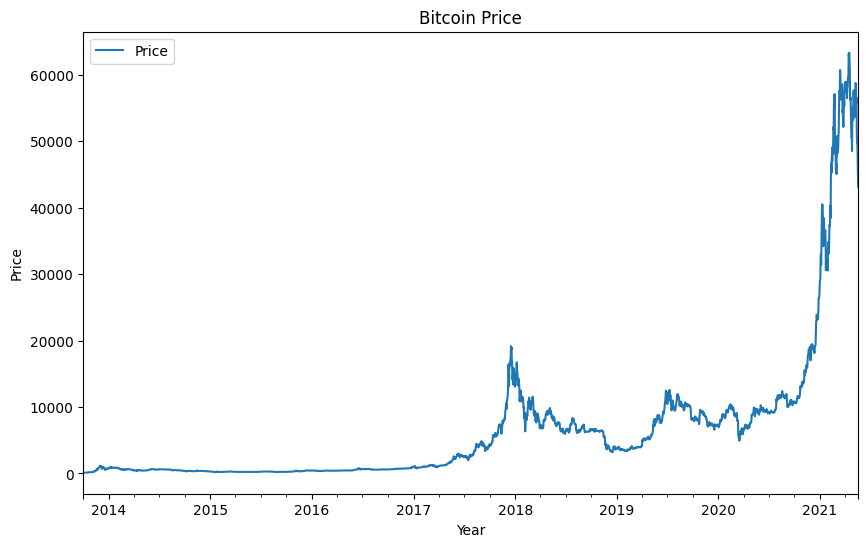

In [11]:
# Plotting The Data:
import matplotlib.pyplot as plt
bitcoin_prices.plot(figsize= (10,6))
plt.xlabel('Year')
plt.ylabel('Price')
plt.title('Bitcoin Price')
plt.show()

### Importing time series data with Python's CSV module

If your time series data comes in CSV form you don't necessarily have to use pandas.

You can use Python's [in-built `csv` module](https://docs.python.org/3/library/csv.html). And if you're working with dates, you might also want to use Python's [`datetime`](https://docs.python.org/3/library/datetime.html).

Let's see how we can replicate the plot we created before except this time using Python's `csv` and `datetime` modules.

Resource:
For a great guide on using Python's `csv` module, check out Real Python's tutorial on [Reading and Writing CSV files in Python](https://realpython.com/python-csv/).

In [12]:
# Importing and formatting historical Bitcoin data with Python:
import csv
from datetime import datetime

timesteps= []
btc_price= []

with open('BTC_USD_2013-10-01_2021-05-18-CoinDesk.csv', mode= 'r') as f:
    csv_reader = csv.reader(f, delimiter= ',') # read in the target CSV
    next(csv_reader) # skip first line (this gets rid of the column titles)
    for line in csv_reader:
        timesteps.append(datetime.strptime(line[1], '%Y-%m-%d')) # get the dates as dates (not strings), strptime = string parse time
        btc_price.append(float(line[2])) # get the closing price as float

# View first 10 of each date and data:
timesteps[:10], btc_price[:10]

([datetime.datetime(2013, 10, 1, 0, 0),
  datetime.datetime(2013, 10, 2, 0, 0),
  datetime.datetime(2013, 10, 3, 0, 0),
  datetime.datetime(2013, 10, 4, 0, 0),
  datetime.datetime(2013, 10, 5, 0, 0),
  datetime.datetime(2013, 10, 6, 0, 0),
  datetime.datetime(2013, 10, 7, 0, 0),
  datetime.datetime(2013, 10, 8, 0, 0),
  datetime.datetime(2013, 10, 9, 0, 0),
  datetime.datetime(2013, 10, 10, 0, 0)],
 [123.65499,
  125.455,
  108.58483,
  118.67466,
  121.33866,
  120.65533,
  121.795,
  123.033,
  124.049,
  125.96116])

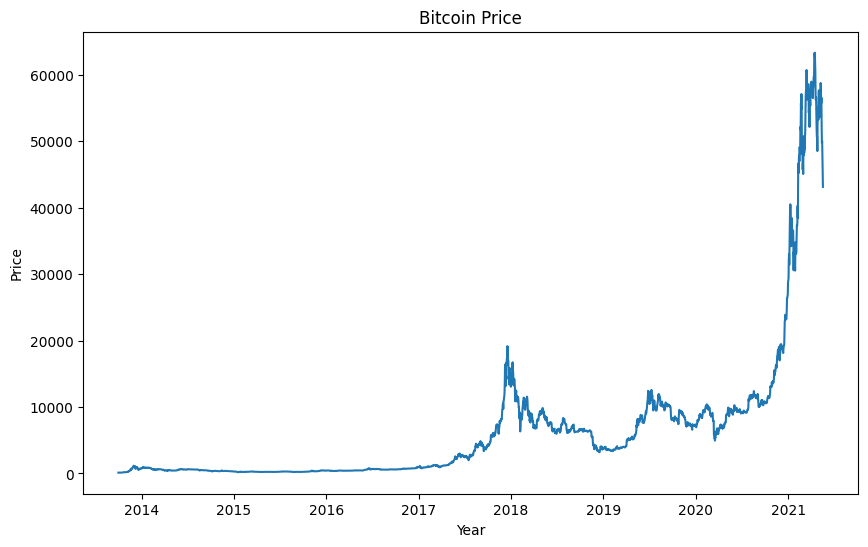

In [13]:
# Plotting The Data:
plt.figure(figsize= (10,6))
plt.plot(timesteps, btc_price)
plt.xlabel('Year')
plt.ylabel('Price')
plt.title('Bitcoin Price')
plt.show()

## Format Data Part 1: Creatining train and test sets for time series data


How about creating train and test splits?

Usually, you could create a train and test split using a function like Scikit-Learn's outstanding [`train_test_split()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) but as we'll see in a moment, this doesn't really cut it for time series data.

But before we do create splits, it's worth talking about what *kind* of data we have.

In time series problems, you'll either have **univariate** or **multivariate** data.

Can you guess what our data is?

* **Univariate** time series data deals with *one* variable, for example, using the price of Bitcoin to predict the price of Bitcoin.
* **Multivariate** time series data deals with *more than one* variable, for example, predicting electricity demand using the day of week, time of year and number of houses in a region.

![comparison of univariate and multivariate time series data](https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/10-univariate-and-multivariate-time-series-data.png)
*Example of univariate and multivariate time series data. Univariate involves using the target to predict the target. Multivariate inolves using the target as well as another time series to predict the target.*

### Create train & test sets for time series (the wrong way)

We've figured out we're dealing with a univariate time series, so we only have to make a split on one variable (for multivariate time series, you will have to split multiple variables). 

How about we first see the *wrong way* for splitting time series data?

Let's turn our DataFrame index and column into NumPy arrays.

In [14]:
# Getting Data and Price into Arrays:
timesteps = bitcoin_prices.index.to_numpy()
prices = bitcoin_prices['Price'].to_numpy()

In [15]:
timesteps[:10], prices[:10]

(array(['2013-10-01T00:00:00.000000000', '2013-10-02T00:00:00.000000000',
        '2013-10-03T00:00:00.000000000', '2013-10-04T00:00:00.000000000',
        '2013-10-05T00:00:00.000000000', '2013-10-06T00:00:00.000000000',
        '2013-10-07T00:00:00.000000000', '2013-10-08T00:00:00.000000000',
        '2013-10-09T00:00:00.000000000', '2013-10-10T00:00:00.000000000'],
       dtype='datetime64[ns]'),
 array([123.65499, 125.455  , 108.58483, 118.67466, 121.33866, 120.65533,
        121.795  , 123.033  , 124.049  , 125.96116]))

In [16]:
# Wrong Way to Make Train and Test Datasets for Time Series:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(timesteps,
                                                   prices,
                                                   test_size= 0.2,
                                                   random_state= 42)

In [17]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2229,), (558,), (2229,), (558,))

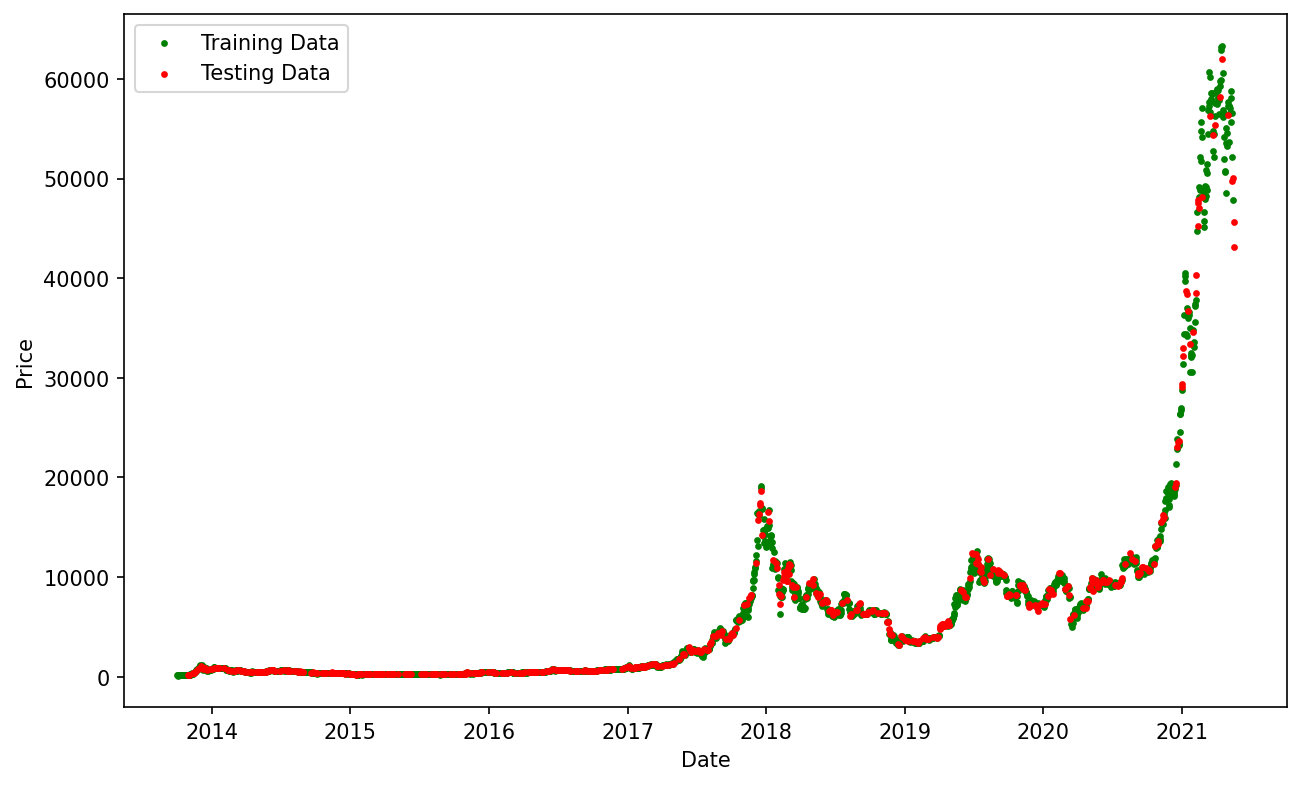

In [18]:
# Plotting Training and Test Data:
plt.figure(figsize= (10,6), dpi= 150)
plt.scatter(X_train, y_train, c= 'green', s=5, label= 'Training Data')
plt.scatter(X_test, y_test, c= 'red', s= 5, label= 'Testing Data')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

What's wrong with this plot?

Well, let's remind ourselves of what we're trying to do.

We're trying to use the historical price of Bitcoin to predict future prices of Bitcoin.

With this in mind, our seen data (training set) is what?

Prices of Bitcoin in the past.

And our unseen data (test set) is?

Prices of Bitcoin in the future. 

Does the plot above reflect this?

No. 

Our test data is scattered all throughout the training data.

This kind of random split is okay for datasets without a time component (such as images or passages of text for classification problems) but for time series, we've got to take the time factor into account.

To fix this, we've got to split our data in a way that reflects what we're actually trying to do.

We need to split our historical Bitcoin data to have a dataset that reflects the past (train set) and a dataset that reflects the future (test set).

### Create train & test sets for time series (the right way)

There's no way we can actually access data from the future.

But we can engineer our test set to be in the future with respect to the training set.

To do this, we can create an abitrary point in time to split our data.

Everything before the point in time can be considered the training set and everything after the point in time can be considered the test set.

![time series train test split](https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/10-time-series-train-test-split.png)
*Demonstration of time series split. Rather than a traditionaly random train/test split, it's best to split the time series data sequentially. Meaning, the test data should be data from the future when compared to the training data.*

In [19]:
# Creating Trainig and Test Datasets for Time Series (Right Way):
split_size = int(0.8 * len(prices)) # 80% train, 20% test

# Training Data:
X_train, y_train = timesteps[:split_size], prices[:split_size]

# Test Data:
X_test, y_test = timesteps[split_size:], prices[split_size:]

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2229,), (558,), (2229,), (558,))

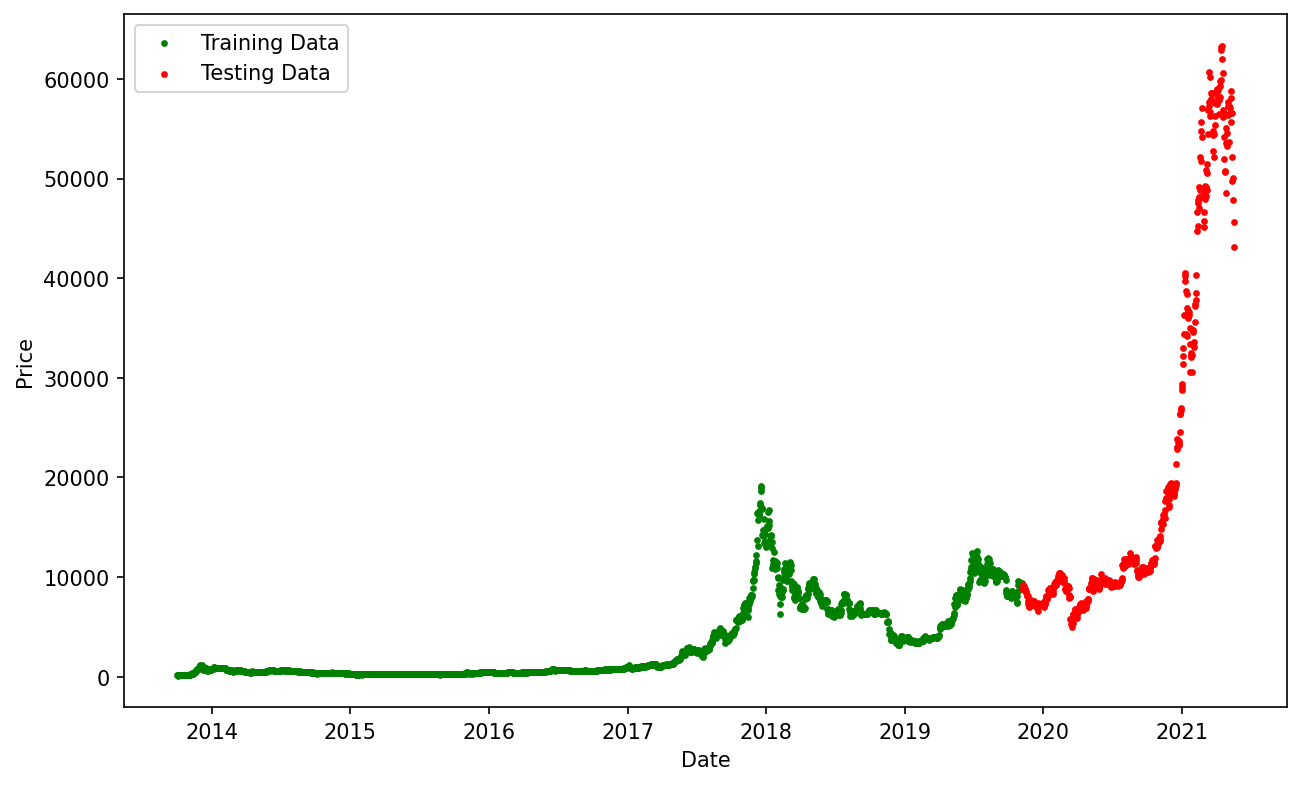

In [20]:
# Plotting Training and Test Data:
plt.figure(figsize= (10,6), dpi= 150)
plt.scatter(X_train, y_train, c= 'green', s=5, label= 'Training Data')
plt.scatter(X_test, y_test, c= 'red', s= 5, label= 'Testing Data')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

We're going to be using the training set (past) to train a model to try and predict values on the test set (future).

Because the test set is an *artificial* future, we can guage how our model might perform on *actual* future data.

> 🔑 **Note:** The amount of data you reserve for your test set not set in stone. You could have 80/20, 90/10, 95/5 splits or in some cases, you might not even have enough data to split into train and test sets (see the resource below). The point is to remember the test set is a pseudofuture and not the actual future, it is only meant to give you an indication of how the models you're building are performing. 

> 📖 **Resource:** Working with time series data can be tricky compared to other kinds of data. And there are a few pitfalls to watch out for, such as how much data to use for a test set. The article [*3 facts about time series forecasting that surprise experienced machine learning practitioners*](https://towardsdatascience.com/3-facts-about-time-series-forecasting-that-surprise-experienced-machine-learning-practitioners-69c18ee89387) talks about different things to watch out for when working with time series data, I'd recommend reading it.

### Create a plotting function

Rather than retyping `matplotlib` commands to continuously plot data, let's make a plotting function we can reuse later.

In [21]:
# Creating a function to plot time series data:

def plot_time_series(timesteps, values, format= '.', start= 0, end= None, labels= None):
    """
    Plots a timesteps (a series of points in time) against values (a series of values 
    across timesteps).
  
    Parameters
    ---------
    timesteps : array of timesteps
    values : array of values across time
    format : style of plot, default "."
    start : where to start the plot (setting a value will index from start of timesteps & values)
    end : where to end the plot (setting a value will index from end of timesteps & values)
    label : label to show on plot of values
    """

    # Plotting The Time Series:
    plt.plot(timesteps[start:end], values[start:end], format, label= labels)
    plt.xlabel('Date')
    plt.ylabel('Price')
    if labels:
        plt.legend()
    plt.grid(visible= True)

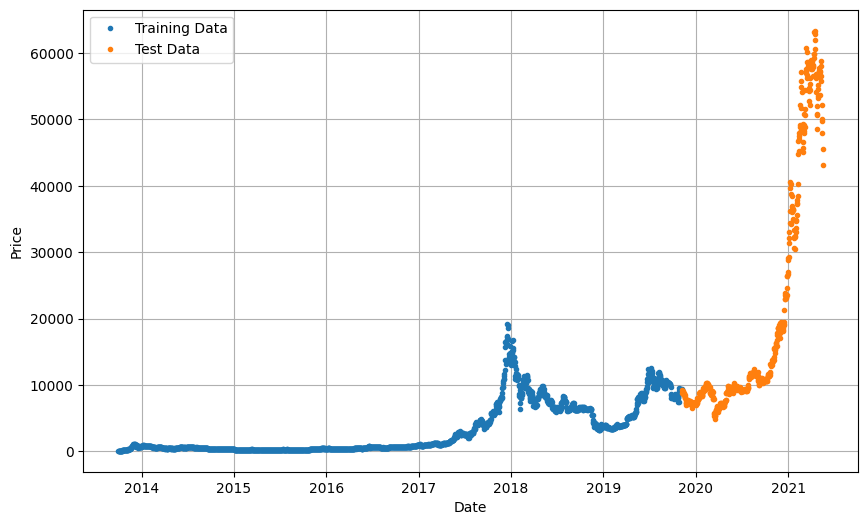

In [22]:
# Testing Out Plotting Function:
plt.figure(figsize= (10,6))
plot_time_series(timesteps= X_train, values= y_train, labels= 'Training Data')
plot_time_series(timesteps= X_test, values= y_test, labels= 'Test Data')

## Modelling Experiments

Before we discuss what modelling experiments we're going to run, there are two terms you should be familiar with, **horizon** and **window**. 
  * **horizon** = number of timesteps to predict into future
  * **window** = number of timesteps from past used to predict **horizon**

For example, if we wanted to predict the price of Bitcoin for tomorrow (1 day in the future) using the previous week's worth of Bitcoin prices (7 days in the past), the horizon would be 1 and the window would be 7.

Modelling Experiments?

| Model Number | Model Type | Horizon size | Window size | Extra data |
| ----- | ----- | ----- | ----- | ----- |
| 0 | Naïve model (baseline) | NA | NA | NA |
| 1 | Dense model | 1 | 7 | NA |
| 2 | Same as 1 | 1 | 30 | NA | 
| 3 | Same as 1 | 7 | 30 | NA |
| 4 | Conv1D | 1 | 7 | NA |
| 5 | LSTM | 1 | 7 | NA |
| 6 | Same as 1 (but with multivariate data) | 1 | 7 | Block reward size |
| 7 | [N-BEATs Algorithm](https://arxiv.org/pdf/1905.10437.pdf) | 1 | 7 | NA |
| 8 | Ensemble (multiple models optimized on different loss functions) | 1 | 7 | NA | 
| 9 | Future prediction model (model to predict future values) | 1 | 7 | NA| 
| 10 | Same as 1 (but with turkey 🦃 data introduced) | 1 | 7 | NA |

Note: To reiterate, as you can see, we can build many types of models for the data we're working with. But that doesn't mean that they'll perform well. Deep learning is a powerful technique but it doesn't always work. And as always, start with a simple model first and then add complexity as needed. 

## Model 0: Naïve forecast (baseline)

One of the most common baseline models for time series forecasting, the naïve model (also called the [naïve forecast](https://otexts.com/fpp3/simple-methods.html#na%C3%AFve-method)), requires no training at all.

That's because all the naïve model does is use the previous timestep value to predict the next timestep value.

The formula looks like this:

$$\hat{y}_{t} = y_{t-1}$$ 

In English: 
> The prediction at timestep `t` (y-hat) is equal to the value at timestep `t-1` (the previous timestep).

In an open system (like a stock market or crypto market), you'll often find beating the naïve forecast with *any* kind of model is quite hard.

Note: For the sake of this notebook, an **open system** is a system where inputs and outputs can freely flow, such as a market (stock or crypto). Where as, a **closed system** the inputs and outputs are contained within the system (like a poker game with your buddies, you know the buy in and you know how much the winner can get). Time series forecasting in **open systems** is generally quite poor.

In [23]:
# Creating Naive Forecast:
naive_forecast = y_test[:-1] # Naïve forecast equals every value excluding the last value
naive_forecast[:10], naive_forecast[-10:]

(array([9226.48582088, 8794.35864452, 8798.04205463, 9081.18687849,
        8711.53433917, 8760.89271814, 8749.52059102, 8656.97092235,
        8500.64355816, 8469.2608989 ]),
 array([57107.12067189, 58788.20967893, 58102.19142623, 55715.54665129,
        56573.5554719 , 52147.82118698, 49764.1320816 , 50032.69313676,
        47885.62525472, 45604.61575361]))

In [24]:
y_test[-10:]

array([58788.20967893, 58102.19142623, 55715.54665129, 56573.5554719 ,
       52147.82118698, 49764.1320816 , 50032.69313676, 47885.62525472,
       45604.61575361, 43144.47129086])

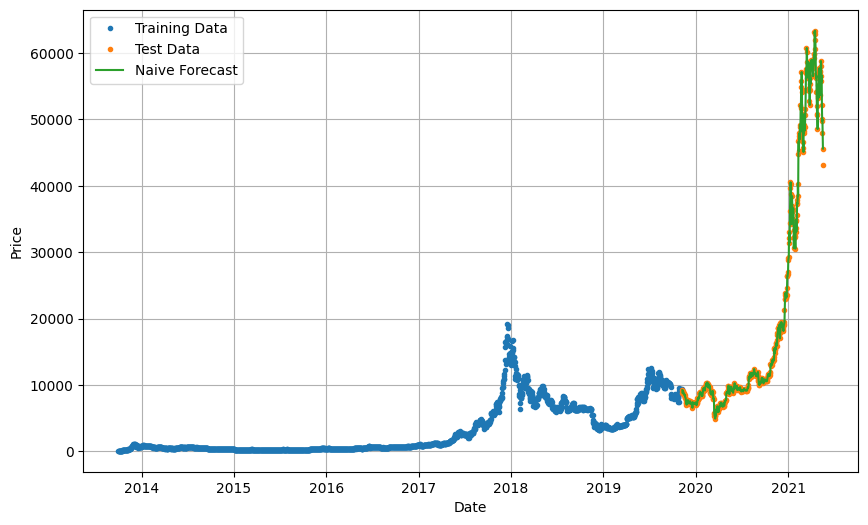

In [25]:
# Plotting Data and Naive Forecast:
plt.figure(figsize= (10,6))
plot_time_series(timesteps= X_train, values= y_train, labels= 'Training Data')
plot_time_series(timesteps= X_test, values= y_test, labels= 'Test Data')
plot_time_series(timesteps= X_test[1:], values= naive_forecast, format= '-', labels= 'Naive Forecast')

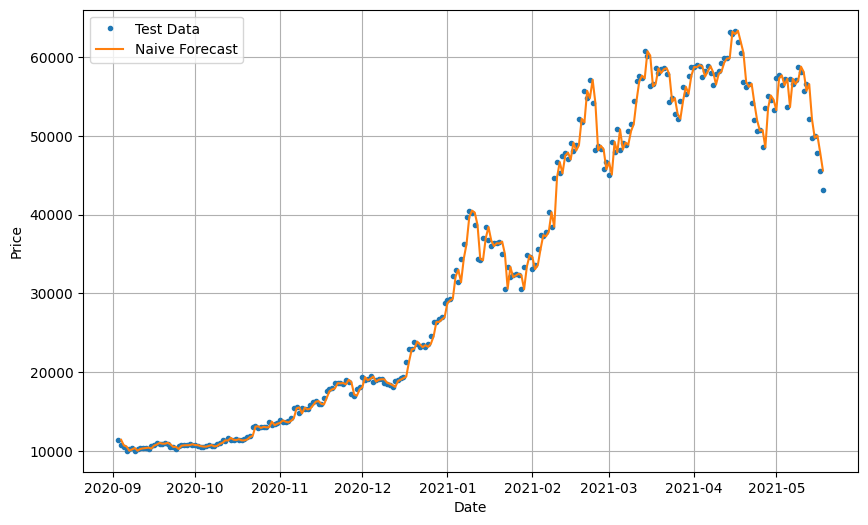

In [26]:
# Zooming in On Test Data and Forecasts:
plt.figure(figsize=(10, 6))
offset = 300 # offset the values by 300 timesteps 
plot_time_series(timesteps=X_test, values=y_test, start=offset, labels='Test Data')
plot_time_series(timesteps=X_test[1:], values=naive_forecast, format='-', start=offset, labels='Naive Forecast')

## Evaluating a time series model

Time series forecasting often involves predicting a number (in our case, the price of Bitcoin).

With this known, we can use regression evaluation metrics to evaluate our time series forecasts.

The main thing we will be evaluating is: **how do our model's predictions (`y_pred`) compare against the actual values (`y_true` or *ground truth values*)**? 

Resource: We're going to be using several metrics to evaluate our different model's time series forecast accuracy. Many of them are sourced and explained mathematically and conceptually in [Forecasting: Principles and Practice chapter 5.8](https://otexts.com/fpp3/accuracy.html).

For all of the following metrics, **lower is better** (for example an MAE of 0 is better than an MAE 100).

### Scale-dependent errors

These are metrics which can be used to compare time series values and forecasts that are on the same scale.

For example, Bitcoin historical prices in USD veresus Bitcoin forecast values in USD.

| Metric | Details | Code |
| ----- | ----- | ----- |
| **MAE** (mean absolute error) | Easy to interpret (a forecast is X amount different from actual amount). Forecast methods which minimises the MAE will lead to forecasts of the median. | [`tf.keras.metrics.mean_absolute_error()`](https://www.tensorflow.org/api_docs/python/tf/keras/metrics/MeanAbsoluteError) |
| **RMSE** (root mean square error) | Forecasts which minimise the RMSE lead to forecasts of the mean. | `tf.sqrt(`[`tf.keras.metrics.mean_square_error()`](https://www.tensorflow.org/api_docs/python/tf/keras/metrics/RootMeanSquaredError)`)`|

### Percentage errors

Percentage errors do not have units, this means they can be used to compare forecasts across different datasets.

| **Metric** | **Details** | **Code** |
| ----- | ----- | ----- |
| **MAPE** (mean absolute percentage error) | Most commonly used percentage error. May explode (not work) if `y=0`. | [`tf.keras.metrics.mean_absolute_percentage_error()`](https://www.tensorflow.org/api_docs/python/tf/keras/losses/MAPE) | 
| **sMAPE** (symmetric mean absolute percentage error) | Recommended not to be used by [Forecasting: Principles and Practice](https://otexts.com/fpp3/accuracy.html#percentage-errors), though it is used in forecasting competitions. | Custom implementation |

### Scaled errors

Scaled errors are an alternative to percentage errors when comparing forecast performance across different time series.

| **Metric** | **Details** | **Code** |
| ----- | ----- | ----- |
| **MASE** (mean absolute scaled error). | MASE equals one for the naive forecast (or very close to one). A forecast which performs better than the naïve should get <1 MASE. | See sktime's [`mase_loss()`](https://github.com/alan-turing-institute/sktime/blob/ee7a06843a44f4aaec7582d847e36073a9ab0566/sktime/performance_metrics/forecasting/_functions.py#L16) |

Question: There are so many metrics... which one should I pay most attention to? It's going to depend on your problem. However, since its ease of interpretation, MAE is often a very good place to start.

Since we're going to be evaluing a lot of models, let's write a function to help us calculate evaluation metrics on their forecasts.

In [27]:
import tensorflow as tf

2026-03-02 12:38:54.535955: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-02 12:38:56.362278: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-02 12:39:00.269842: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [28]:
# MASE Implementation 
# sktime - https://github.com/alan-turing-institute/sktime/blob/ee7a06843a44f4aaec7582d847e36073a9ab0566/sktime/performance_metrics/forecasting/_functions.py#L16

def mean_absolute_scaled_error(y_true, y_pred):
    """
    Implement MASE (assuming no seasonality of data).
    """

    mae = tf.reduce_mean(tf.abs(y_true - y_pred))

    # MAE of Naive Forecast (No Seasonality):
    mae_naive_no_seasonality = tf.reduce_mean(tf.abs((y_true[1:] - y_true[:-1]))) # our seasonality is 1 day (hence the shifting of 1 day)


    return mae / mae_naive_no_seasonality

You'll notice the version of MASE above doesn't take in the training values like sktime's `mae_loss()`. In our case, we're comparing the MAE of our predictions on the test to the MAE of the naïve forecast on the test set.

In practice, if we've created the function correctly, the naïve model should achieve an MASE of 1 (or very close to 1). Any model worse than the naïve forecast will achieve an MASE of >1 and any model better than the naïve forecast will achieve an MASE of <1.

Let's put each of our different evaluation metrics together into a function.

In [29]:
# Creating a Function to take in True Values and Model Predictions and Return Evaluation Metrics:

def evaluate_preds(y_true, y_pred):

    # Make sure float32 (for metric calculations):
    y_true = tf.cast(y_true, dtype= tf.float32)
    y_pred = tf.cast(y_pred, dtype= tf.float32)

    # Calculating Various Metrics:
    mae = tf.keras.metrics.mean_absolute_error(y_true, y_pred)
    mse = tf.keras.metrics.mean_squared_error(y_true, y_pred)
    rmse = tf.sqrt(mse)
    mape = tf.keras.metrics.mean_absolute_percentage_error(y_true, y_pred)
    mase = mean_absolute_scaled_error(y_true, y_pred)

    return {
        'mae': mae.numpy(),
        'mse': mse.numpy(),
        'rmse': rmse.numpy(),
        'mape': mape.numpy(),
        'mase': mase.numpy()
    }

In [30]:
# Calculating Evaluation Metrics for naive Forecast Model:
naive_results = evaluate_preds(y_true= y_test[1:],
                              y_pred= naive_forecast)
naive_results

I0000 00:00:1772455147.261427     757 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9507 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


{'mae': 567.9802,
 'mse': 1147547.0,
 'rmse': 1071.2362,
 'mape': 2.516525,
 'mase': 0.99957}

Taking a look at the naïve forecast's MAE, it seems on average each forecast is ~$567 different than the actual Bitcoin price.

How does this compare to the average price of Bitcoin in the test dataset?

In [31]:
# Find Average Price of Bitcoin in Test Dataset:
tf.reduce_mean(y_test).numpy()

20056.632963737222

In [32]:
tf.reduce_min(y_test).numpy(), tf.reduce_max(y_test).numpy()

(4944.7023359837, 63346.7890351052)

Okay, looking at these two values is starting to give us an idea of how our model is performing:
* The average price of Bitcoin in the test dataset is: $20,056 (note: average may not be the best measure here, since the highest price is over 3x this value and the lowest price is over 4x lower)

* Each prediction in naive forecast is on average off by: $567

Is this enough to say it's a good model?

That's up your own interpretation.

## Other kinds of time series forecasting models which can be used for baselines and actual forecasts

Since we've got a naïve forecast baseline to work with, it's time we start building models to try and beat it.

And because this file is focused on TensorFlow and deep learning, we're going to be using TensorFlow to build deep learning models to try and improve on our naïve forecasting results.

That being said, there are many other kinds of models you may want to look into for building baselines/performing forecasts.

Some of them may even beat our best performing models in this notebook. [Some of which are intlempented here using Scikit-Learn Library](<https://github.com/Shailya-Ds-Or/Machine-Learning/tree/main/10)%20Time%20Series%20Analysis%20and%20Modeling>)

| **Model/Library Name** | **Resource** |
| ----- | ----- |
| Moving average | https://machinelearningmastery.com/moving-average-smoothing-for-time-series-forecasting-python/ |
| ARIMA (Autoregression Integrated Moving Average) | https://machinelearningmastery.com/arima-for-time-series-forecasting-with-python/ |
| sktime (Scikit-Learn for time series) | https://github.com/alan-turing-institute/sktime |
| TensorFlow Decision Forests (random forest, gradient boosting trees) | https://www.tensorflow.org/decision_forests |
| Facebook Kats (purpose-built forecasting and time series analysis library by Facebook) | https://github.com/facebookresearch/Kats | 
| LinkedIn Greykite (flexible, intuitive and fast forecasts) | https://github.com/linkedin/greykite |

## Format Data Part 2: Windowing dataset

We've got to window our time series.

Why do we window?

Windowing is a method to turn a time series dataset into **supervised learning problem**. 

In other words, we want to use windows of the past to predict the future.

For example for a univariate time series, windowing for one week (`window=7`) to predict the next single value (`horizon=1`) might look like:

```
Window for one week (univariate time series)

[0, 1, 2, 3, 4, 5, 6] -> [7]
[1, 2, 3, 4, 5, 6, 7] -> [8]
[2, 3, 4, 5, 6, 7, 8] -> [9]
```

Or for the price of Bitcoin, it'd look like:

```
Window for one week with the target of predicting the next day (Bitcoin prices)

[123.654, 125.455, 108.584, 118.674, 121.338, 120.655, 121.795] -> [123.033]
[125.455, 108.584, 118.674, 121.338, 120.655, 121.795, 123.033] -> [124.049]
[108.584, 118.674, 121.338, 120.655, 121.795, 123.033, 124.049] -> [125.961]
```

![windows and horizons for turning time series data into a supervised learning problem](https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/10-time-series-windows-and-horizons.png)
*Example of windows and horizons for Bitcoin data. Windowing can be used to turn time series data into a supervised learning problem.*

Let's build some functions which take in a univariate time series and turn it into windows and horizons of specified sizes.

We'll start with the default horizon size of 1 and a window size of 7 (these aren't necessarily the best values to use).

In [33]:
HORIZON = 1 # predict 1 step at a time
WINDOW_SIZE = 7 # use a week worth of timesteps to predict the horizon

In [34]:
# Creating a Function tp Label Windowed Data:
def get_labeled_windows(x, horizon= 1):
    """
    Creates labels for windowed dataset.

    E.g. if horizon=1 (default)
    Input: [0, 1, 2, 3, 4, 5, 6, 7] -> Output: ([0, 1, 2, 3, 4, 5, 6], [7])
    """
    return (x[:, :-horizon], x[:, -horizon:])

In [35]:
# Testing out The Window Labelling Function:
test_window, test_label = get_labeled_windows(tf.expand_dims(tf.range(8), axis= 0), horizon= HORIZON)

In [36]:
test_window, test_label

(<tf.Tensor: shape=(1, 7), dtype=int32, numpy=array([[0, 1, 2, 3, 4, 5, 6]], dtype=int32)>,
 <tf.Tensor: shape=(1, 1), dtype=int32, numpy=array([[7]], dtype=int32)>)

Now we need a way to make windows for an entire time series.

We could do this with Python for loops, however, for large time series, that'd be quite slow.

To speed things up, we'll leverage [NumPy's array indexing](https://numpy.org/doc/stable/reference/arrays.indexing.html).

Let's write a function which:
1. Creates a window step of specific window size, for example: `[[0, 1, 2, 3, 4, 5, 6, 7]]`
2. Uses NumPy indexing to create a 2D of multiple window steps, for example: 
```
[[0, 1, 2, 3, 4, 5, 6, 7],
 [1, 2, 3, 4, 5, 6, 7, 8],
 [2, 3, 4, 5, 6, 7, 8, 9]]
```
3. Uses the 2D array of multuple window steps to index on a target series
4. Uses the `get_labelled_windows()` function we created above to turn the window steps into windows with a specified horizon

Resource: The function created below has been adapted from Syafiq Kamarul Azman's article [*Fast and Robust Sliding Window Vectorization with NumPy*](https://towardsdatascience.com/fast-and-robust-sliding-window-vectorization-with-numpy-3ad950ed62f5).

In [37]:
import numpy as np

In [38]:
# Creating a Function to View Numpy Arrays as Windows:
def make_windows(x, window_size= 7, horizon= 1):
    """
    Turns a 1D array into a 2D array of sequential windows of window_size.
    """

    # 1. Create a window of specific window_size (add the horizon on the end for later labelling):
    window_step = np.expand_dims(np.arange(window_size + horizon), axis= 0)
    #print(f"Window step:\n {window_step}")

    # 2. Create a 2D array of multiple window steps (minus 1 to account for 0 indexing):
    window_indexes = window_step + np.expand_dims(np.arange(len(x) - (window_size + horizon - 1)), axis= 0).T
    #print(f"Window indexes:\n {window_indexes[:3], window_indexes[-3:], window_indexes.shape}")

    # 3. Index on the target array (time series) with 2D array of multiple window steps:
    windowed_array = x[window_indexes]

    # 4. get The Labeled Windows:
    windows, labels = get_labeled_windows(windowed_array, horizon= horizon)

    return windows, labels

In [39]:
full_windows, full_labels = make_windows(prices, window_size= 7, horizon= 1)
full_windows.shape, full_labels.shape

((2780, 7), (2780, 1))

In [40]:
full_windows[:3]

array([[123.65499, 125.455  , 108.58483, 118.67466, 121.33866, 120.65533,
        121.795  ],
       [125.455  , 108.58483, 118.67466, 121.33866, 120.65533, 121.795  ,
        123.033  ],
       [108.58483, 118.67466, 121.33866, 120.65533, 121.795  , 123.033  ,
        124.049  ]])

In [41]:
full_labels[:3]

array([[123.033  ],
       [124.049  ],
       [125.96116]])

In [42]:
# View the first 3 windows/labels
for i in range(3):
  print(f"Window: {full_windows[i]} -> Label: {full_labels[i]}")

Window: [123.65499 125.455   108.58483 118.67466 121.33866 120.65533 121.795  ] -> Label: [123.033]
Window: [125.455   108.58483 118.67466 121.33866 120.65533 121.795   123.033  ] -> Label: [124.049]
Window: [108.58483 118.67466 121.33866 120.65533 121.795   123.033   124.049  ] -> Label: [125.96116]


In [43]:
# View the last 3 windows/labels
for i in range(3):
  print(f"Window: {full_windows[i-3]} -> Label: {full_labels[i-3]}")

Window: [58788.20967893 58102.19142623 55715.54665129 56573.5554719
 52147.82118698 49764.1320816  50032.69313676] -> Label: [47885.62525472]
Window: [58102.19142623 55715.54665129 56573.5554719  52147.82118698
 49764.1320816  50032.69313676 47885.62525472] -> Label: [45604.61575361]
Window: [55715.54665129 56573.5554719  52147.82118698 49764.1320816
 50032.69313676 47885.62525472 45604.61575361] -> Label: [43144.47129086]


> 🔑 **Note:** You can find a function which achieves similar results to the ones we implemented above at [`tf.keras.preprocessing.timeseries_dataset_from_array()`](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/timeseries_dataset_from_array). Just like ours, it takes in an array and returns a windowed dataset. It has the benefit of returning data in the form of a tf.data.Dataset instance (we'll see how to do this with our own data later).

## Turning windows into training and test sets 

Time to turn our windows into training and test splits.

We could've windowed our existing training and test splits, however, with the nature of windowing (windowing often requires an offset at some point in the data), it usually works better to window the data first, then split it into training and test sets.

Let's write a function which takes in full sets of windows and their labels and splits them into train and test splits.

In [44]:
# Making Train Test Split:
def make_train_test_splits(windows, labels, test_spilt= 0.2):
    """
    Splits matching pairs of windows and labels into train and test splits.
    """
    split_size = int(len(windows) * (1 - test_spilt)) # this will default to 80% train/20% test
    train_windows = windows[:split_size]
    train_labels = labels[:split_size]
    test_windows = windows[split_size:]
    test_labels = labels[split_size:]

    return train_windows, test_windows, train_labels, test_labels

In [45]:
# Creating Training and Test Windows and Labels:
train_windows, test_windows, train_labels, test_labels = make_train_test_splits(windows= full_windows,
                                                                               labels= full_labels,
                                                                               test_spilt= 0.2)
len(train_windows), len(test_windows), len(train_labels), len(test_labels)

(2224, 556, 2224, 556)

In [46]:
train_windows[:5], train_labels[:5]

(array([[123.65499, 125.455  , 108.58483, 118.67466, 121.33866, 120.65533,
         121.795  ],
        [125.455  , 108.58483, 118.67466, 121.33866, 120.65533, 121.795  ,
         123.033  ],
        [108.58483, 118.67466, 121.33866, 120.65533, 121.795  , 123.033  ,
         124.049  ],
        [118.67466, 121.33866, 120.65533, 121.795  , 123.033  , 124.049  ,
         125.96116],
        [121.33866, 120.65533, 121.795  , 123.033  , 124.049  , 125.96116,
         125.27966]]),
 array([[123.033  ],
        [124.049  ],
        [125.96116],
        [125.27966],
        [125.9275 ]]))

In [47]:
test_windows[:5], test_labels[:5]

(array([[9290.89660239, 9202.41545055, 9369.62808116, 9326.59962378,
         9335.75240233, 9226.48582088, 8794.35864452],
        [9202.41545055, 9369.62808116, 9326.59962378, 9335.75240233,
         9226.48582088, 8794.35864452, 8798.04205463],
        [9369.62808116, 9326.59962378, 9335.75240233, 9226.48582088,
         8794.35864452, 8798.04205463, 9081.18687849],
        [9326.59962378, 9335.75240233, 9226.48582088, 8794.35864452,
         8798.04205463, 9081.18687849, 8711.53433917],
        [9335.75240233, 9226.48582088, 8794.35864452, 8798.04205463,
         9081.18687849, 8711.53433917, 8760.89271814]]),
 array([[8798.04205463],
        [9081.18687849],
        [8711.53433917],
        [8760.89271814],
        [8749.52059102]]))

In [48]:
train_windows.shape, test_windows.shape, train_labels.shape, test_labels.shape

((2224, 7), (556, 7), (2224, 1), (556, 1))

In [49]:
# Check to see if same (accounting for horizon and window size):
np.array_equal(np.squeeze(train_labels[:-HORIZON-1]), y_train[WINDOW_SIZE:])

True

## Make a modelling checkpoint

Because our model's performance will fluctuate from experiment to experiment, we'll want to make sure we're comparing apples to apples.

What I mean by this is in order for a fair comparison, we want to compare each model's best performance against each model's best performance.

For example, if `model_1` performed incredibly well on epoch 55 but its performance fell off toward epoch 100, we want the version of the model from epoch 55 to compare to other models rather than the version of the model from epoch 100.

And the same goes for each of our other models: compare the best against the best.

To take of this, we'll implement a [`ModelCheckpoint`](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/ModelCheckpoint) callback.

The `ModelCheckpoint` callback will monitor our model's performance during training and save the best model to file by setting `save_best_only=True`.

That way when evaluating our model we could restore its best performing configuration from file.

> 🔑 **Note:** Because of the size of the dataset (smaller than usual), you'll notice our modelling experiment results fluctuate quite a bit during training (hence the implementation of the `ModelCheckpoint` callback to save the best model).

Because we're going to be running multiple experiments, it makes sense to keep track of them by saving models to file under different names.

To do this, we'll write a small function to create a `ModelCheckpoint` callback which saves a model to specified filename.

In [50]:
import os

# Create a function to implement a ModelCheckpoint callback with a specific filename:
def create_model_checkpoint(model_name, save_path= 'time_series_model_experiments'):
    return tf.keras.callbacks.ModelCheckpoint(filepath= os.path.join(save_path, model_name+''+'.keras'), # create filepath to save model
                                             save_best_only= True, # save only the best model to file
                                             verbose= 0) # only output a limited amount of text  

## Model 1: Dense model (window = 7, horizon = 1)

Time to build one of our models.

Often, preparing data for a model is one of the largest parts of any machine learning project.

And once you've got a good model in place, you'll probably notice far more improvements from manipulating the data (e.g. collecting more, improving the quality) than manipulating the model.

We're going to start by keeping it simple, `model_1` will have:
* A single dense layer with 128 hidden units and ReLU (rectified linear unit) activation
* An output layer with linear activation (or no activation)
* Adam optimizer and MAE loss function
* Batch size of 128
* 100 epochs


A batch size of 32 works pretty well too and we could always train for less epochs but since the model runs so fast (you'll see in a second, it's because the number of samples we have isn't massive) we might as well train for more.

> 🔑 **Note:** As always, many of the values for machine learning problems are experimental. A reminder that the values you can set yourself in a machine learning algorithm (the hidden units, the batch size, horizon size, window size) are called [**hyperparameters**](https://en.wikipedia.org/wiki/Hyperparameter_(machine_learning). And experimenting to find the best values for hyperparameters is called **hyperparameter tuning**. Where as parameters learned by a model itself (patterns in the data, formally called weights & biases) are referred to as **parameters**.

In [51]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Lambda, Conv1D, LSTM, Input, add, subtract
from tensorflow.keras.metrics import mae
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

In [52]:
# Setting Random Seed:
tf.random.set_seed(42)

# Creating Model:
model_1 = Sequential(name= 'Model_1_Dense')
model_1.add(Dense(units= 128, activation= 'relu'))
model_1.add(Dense(units= HORIZON, activation= 'linear')) # linear activation is the same as having no activation

# Compiling The Model:
model_1.compile(optimizer= Adam(),
               loss= mae,
               metrics= ['mae'])

# Fitting The Model:
model_1_history = model_1.fit(x= train_windows,
                             y= train_labels,
                             epochs= 100,
                             batch_size= 128,
                             validation_data= (test_windows, test_labels),
                             callbacks= [create_model_checkpoint(model_name= model_1.name)])

Epoch 1/100


2026-03-02 12:39:11.841173: I external/local_xla/xla/service/service.cc:163] XLA service 0x769cfeaa9060 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-02 12:39:11.841225: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4080 Laptop GPU, Compute Capability 8.9
2026-03-02 12:39:11.875577: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-02 12:39:11.959722: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701
I0000 00:00:1772455152.482627     910 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


18/18 [==============================] - 2s 24ms/step - loss: 3317.1218 - mae: 3317.1218 - val_loss: 7179.2959 - val_mae: 7179.2959
Epoch 2/100
18/18 [==============================] - 0s 16ms/step - loss: 473.6628 - mae: 473.6628 - val_loss: 936.6224 - val_mae: 936.6224
Epoch 3/100
18/18 [==============================] - 0s 16ms/step - loss: 205.2556 - mae: 205.2556 - val_loss: 883.1871 - val_mae: 883.1871
Epoch 4/100
18/18 [==============================] - 0s 14ms/step - loss: 154.4452 - mae: 154.4452 - val_loss: 811.9825 - val_mae: 811.9825
Epoch 5/100
18/18 [==============================] - 0s 10ms/step - loss: 148.8724 - mae: 148.8724 - val_loss: 837.9614 - val_mae: 837.9614
Epoch 6/100
18/18 [==============================] - 0s 12ms/step - loss: 146.8033 - mae: 146.8033 - val_loss: 788.0379 - val_mae: 788.0379
Epoch 7/100
18/18 [==============================] - 0s 12ms/step - loss: 139.8853 - mae: 139.8853 - val_loss: 768.2361 - val_mae: 768.2361
Epoch 8/100
18/18 [=========

In [53]:
# Evaluating Model on Test Data:
model_1.evaluate(test_windows, test_labels)

18/18 [==============================] - 0s 10ms/step - loss: 679.2894 - mae: 679.2894


[679.2894287109375, 679.2894287109375]

In [54]:
# Load in saved best performing model_1 and evaluate on test data:
model_1 = tf.keras.models.load_model('time_series_model_experiments/Model_1_Dense.keras')
model_1.evaluate(test_windows, test_labels)

18/18 [==============================] - 0s 9ms/step - loss: 569.5345 - mae: 569.5345


[569.5344848632812, 569.5344848632812]

## Making forecasts with a model (on the test dataset)

We've trained a model and evaluated the it on the test data, but the project we're working on is called BitPredict 💰📈 so how do you think we could use our model to make predictions?

Since we're going to be running more modelling experiments, let's write a function which: 
1. Takes in a trained model (just like `model_1`)
2. Takes in some input data (just like the data the model was trained on) 
3. Passes the input data to the model's `predict()` method
4. Returns the predictions.

In [55]:
def make_preds(model, input_data):
    """
    Uses model to make predictions on input_data.

    Parameters
    ----------
    model: trained model 
    input_data: windowed input data (same kind of data model was trained on)

    Returns model predictions on input_data.
    """
    forecast = model.predict(input_data)
    return tf.squeeze(forecast) # returns 1D array of predictions

In [56]:
# Making Predictions Using Model 1 on Test Data:
model_1_preds = make_preds(model= model_1,
                          input_data= test_windows)
model_1_preds[:10], len(model_1_preds)

18/18 [==============================] - 0s 5ms/step


(<tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([8832.533, 8758.585, 9024.551, 8756.054, 8729.018, 8756.463,
        8635.556, 8505.123, 8458.996, 8506.381], dtype=float32)>,
 556)

|> 🔑 **Note:** With these outputs, our model isn't *forecasting* yet. It's only making predictions on the test dataset. Forecasting would involve a model making predictions into the future, however, the test dataset is only a pseudofuture.

In [57]:
# Calculating Metrics for Model 1:
model_1_results = evaluate_preds(y_true= tf.squeeze(test_labels),
                                y_pred= model_1_preds)
model_1_results

{'mae': 569.53455,
 'mse': 1167328.4,
 'rmse': 1080.4297,
 'mape': 2.5391989,
 'mase': 1.0005145}

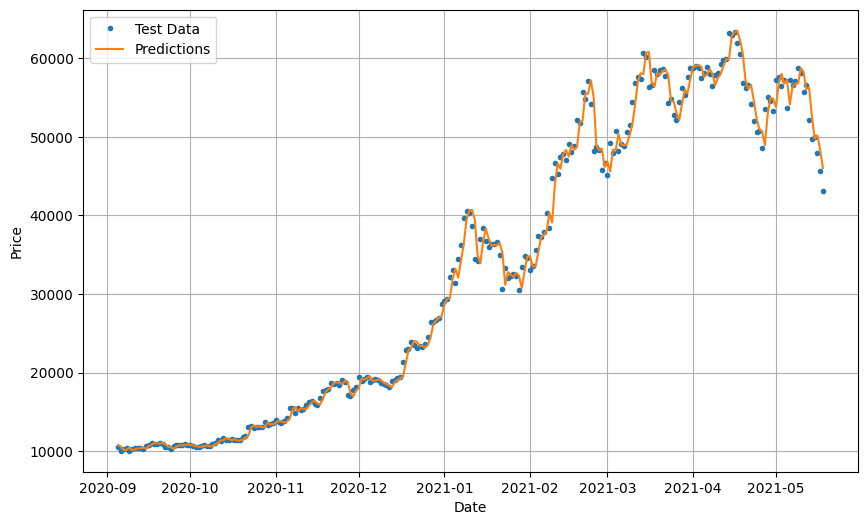

In [58]:
# Plotting Model Predictions:
offset= 300
plt.figure(figsize= (10,6))
plot_time_series(timesteps=X_test[-len(test_windows):], values= test_labels[:, 0], start= offset, labels= 'Test Data')
plot_time_series(timesteps= X_test[-len(test_windows):], values= model_1_preds, start= offset, format= '-', labels= 'Predictions')

## Model 2: Dense (window = 30, horizon = 1)


We'll keep the previous model architecture but use a window size of 30.

In other words, we'll use the previous 30 days of Bitcoin prices to try and predict the next day price.

![bitcoin prices windowed for 30 days to predict a horizon of 1 day](https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/10-bitcoin-price-window-for-one-month.png)
*Example of Bitcoin prices windowed for 30 days to predict a horizon of 1.*

> 🔑 **Note:** Recall from before, the window size (how many timesteps to use to fuel a forecast) and the horizon (how many timesteps to predict into the future) are **hyperparameters**. This means you can tune them to try and find values will result in better performance.

We'll start our second modelling experiment by preparing datasets using the functions we created earlier.

In [59]:
HORIZON = 1 # predict one step at a time
WINDOW_SIZE = 30 # Use 30 timesteps in the past

In [60]:
# Making Windowed Data and Labels with New Window and Horizon Sizes:
full_windows, full_labels = make_windows(x= prices,
                                        window_size= WINDOW_SIZE,
                                        horizon= HORIZON)
full_windows.shape, full_labels.shape

((2757, 30), (2757, 1))

In [61]:
# Making Train and Test Split Datasets:
train_windows, test_windows, train_labels, test_labels = make_train_test_splits(windows= full_windows,
                                                                               labels= full_labels,
                                                                               test_spilt= 0.2)
train_windows.shape, test_windows.shape, train_windows.shape, train_labels.shape

((2205, 30), (552, 30), (2205, 30), (2205, 1))

In [62]:
# Creating Model:
tf.random.set_seed(42)

model_2 = Sequential(name= 'Model_2_Dense')
model_2.add(Dense(units= 128, activation= 'relu'))
model_2.add(Dense(units= HORIZON, activation= 'linear'))

# Compiling The Model:
model_2.compile(optimizer= Adam(),
               loss= mae,
               metrics= ['mae'])

# Fitting The Model:
model_2_history = model_2.fit(x= train_windows,
                             y= train_labels,
                             epochs= 100,
                             batch_size= 128,
                             verbose= 0,
                             validation_data= (test_windows, test_labels),
                             callbacks= [create_model_checkpoint(model_name= model_2.name)])

In [63]:
# Evaluating Model 2 on Test Data:
model_2.evaluate(test_windows, test_labels)

18/18 [==============================] - 0s 6ms/step - loss: 611.1639 - mae: 611.1639


[611.1638793945312, 611.1638793945312]

In [64]:
# Load in saved best performing model_2 and evaluate on test data:
model_2 = tf.keras.models.load_model("time_series_model_experiments/Model_2_Dense.keras")
model_2.evaluate(test_windows, test_labels)

18/18 [==============================] - 0s 7ms/step - loss: 608.8109 - mae: 608.8109


[608.8108520507812, 608.8108520507812]

In [65]:
# Get Predictions on Test Data:
model_2_preds = make_preds(model_2, test_windows)
model_2_preds[:10]

18/18 [==============================] - 0s 3ms/step


<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([8732.211 , 8784.24  , 8717.181 , 8544.956 , 8454.286 , 8480.936 ,
       8201.93  , 8130.7256, 8042.8813, 7753.433 ], dtype=float32)>

In [66]:
# Calculating Metrics for Model 2:
model_2_results= evaluate_preds(y_true= tf.squeeze(test_labels),
                               y_pred= model_2_preds)
model_2_results

{'mae': 608.8108,
 'mse': 1313858.1,
 'rmse': 1146.2365,
 'mape': 2.7350101,
 'mase': 1.0642072}

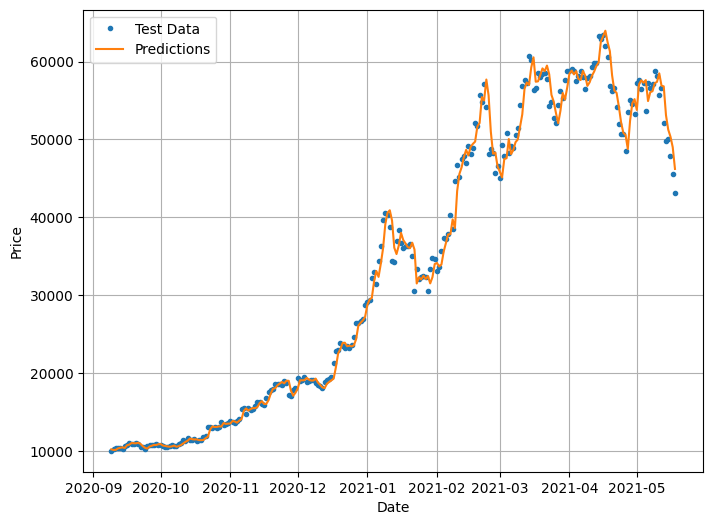

In [67]:
# Plotting Model Predictions:
offset= 300
plt.figure(figsize= (8,6))
plot_time_series(timesteps= X_test[-len(test_windows):], values= test_labels[:, 0], start= offset, labels= 'Test Data')
plot_time_series(timesteps= X_test[-len(test_windows):], values= model_2_preds, start= offset, format= '-', labels= 'Predictions')

## Model 3: Dense (window = 30, horizon = 7)

Let's try and predict 7 days ahead given the previous 30 days.

First, we'll update the `HORIZON` and `WINDOW_SIZE` variables and create windowed data.

In [68]:
HORIZON = 7
WINDOW_SIZE = 30

In [69]:
full_windows, full_labels = make_windows(x= prices, window_size= WINDOW_SIZE, horizon= HORIZON)
full_windows.shape, full_labels.shape

((2751, 30), (2751, 7))

In [70]:
train_windows, test_windows, train_labels, test_labels= make_train_test_splits(windows= full_windows,
                                                                              labels= full_labels,
                                                                              test_spilt= 0.2)
train_windows.shape, test_windows.shape, train_labels.shape, test_labels.shape

((2200, 30), (551, 30), (2200, 7), (551, 7))

In [71]:
# Creating The Model:

tf.random.set_seed(42)

model_3 = Sequential(name= 'Model_3_Dense')
model_3.add(Dense(units= 128, activation= "relu"))
model_3.add(Dense(units= HORIZON, activation= "linear"))

# Compiling The Model:
model_3.compile(optimizer= Adam(),
               loss= mae,
               metrics= ['mae'])

# Fitting The Model:
model_3_history = model_3.fit(x= train_windows,
                             y= train_labels,
                             validation_data= (test_windows, test_labels),
                             epochs= 100,
                             batch_size= 128,
                             callbacks= [create_model_checkpoint(model_name= model_3.name)])

Epoch 1/100
18/18 [==============================] - 1s 23ms/step - loss: 1410.0535 - mae: 1410.0535 - val_loss: 3100.2061 - val_mae: 3100.2061
Epoch 2/100
18/18 [==============================] - 0s 16ms/step - loss: 497.7950 - mae: 497.7950 - val_loss: 2592.6169 - val_mae: 2592.6169
Epoch 3/100
18/18 [==============================] - 0s 15ms/step - loss: 392.8324 - mae: 392.8324 - val_loss: 2101.0879 - val_mae: 2101.0879
Epoch 4/100
18/18 [==============================] - 0s 16ms/step - loss: 355.0251 - mae: 355.0251 - val_loss: 1871.3340 - val_mae: 1871.3340
Epoch 5/100
18/18 [==============================] - 0s 13ms/step - loss: 329.3224 - mae: 329.3224 - val_loss: 1912.8069 - val_mae: 1912.8069
Epoch 6/100
18/18 [==============================] - 0s 13ms/step - loss: 309.9208 - mae: 309.9208 - val_loss: 1681.7738 - val_mae: 1681.7738
Epoch 7/100
18/18 [==============================] - 0s 12ms/step - loss: 291.6451 - mae: 291.6451 - val_loss: 1540.0277 - val_mae: 1540.0277
Epoc

In [72]:
# Evaluating The Model:
model_3.evaluate(test_windows, test_labels)

18/18 [==============================] - 0s 7ms/step - loss: 1298.9514 - mae: 1298.9514


[1298.951416015625, 1298.951416015625]

In [73]:
# Load in saved best performing model_3 and evaluate on test data:
model_3 = tf.keras.models.load_model('time_series_model_experiments/Model_3_Dense.keras')
model_3.evaluate(test_windows, test_labels)

18/18 [==============================] - -2s -122685us/step - loss: 1232.2485 - mae: 1232.2485


[1232.24853515625, 1232.24853515625]

In [74]:
# Get Predictions on Test Data:
model_3_preds = make_preds(model_3, test_windows)
model_3_preds[:10]

18/18 [==============================] - 0s 4ms/step


<tf.Tensor: shape=(10, 7), dtype=float32, numpy=
array([[9528.522 , 9518.389 , 9471.428 , 9417.596 , 9447.873 , 9263.168 ,
        9407.272 ],
       [9131.189 , 9195.5205, 9107.365 , 9168.701 , 9178.484 , 9034.489 ,
        9099.63  ],
       [8836.278 , 9103.21  , 8876.159 , 9154.085 , 8984.52  , 8863.182 ,
        9084.687 ],
       [8921.979 , 9080.625 , 8989.887 , 9181.173 , 9078.213 , 9101.352 ,
        9090.326 ],
       [8828.536 , 8940.925 , 8873.04  , 8959.559 , 9017.798 , 9139.016 ,
        8763.074 ],
       [8831.905 , 9035.275 , 8993.0205, 9073.533 , 8931.6045, 8877.709 ,
        8583.424 ],
       [8946.623 , 8896.008 , 9020.132 , 9086.586 , 8895.839 , 8767.26  ,
        8561.232 ],
       [8632.842 , 8778.068 , 8690.803 , 8801.098 , 8733.93  , 8369.885 ,
        8679.79  ],
       [8811.742 , 8634.787 , 8487.05  , 8530.111 , 8621.033 , 8293.917 ,
        8382.474 ],
       [8661.146 , 8609.632 , 8239.558 , 8419.841 , 8453.009 , 8364.186 ,
        8169.8896]], dtype=floa

In [75]:
model_3_preds.shape, model_2_preds.shape, model_1_preds.shape

(TensorShape([551, 7]), TensorShape([552]), TensorShape([556]))

## Make our evaluation function work for larger horizons

You'll notice the outputs for `model_3_preds` are multi-dimensional. 

This is because the predictions are getting evaluated across the `HORIZON` timesteps (7 predictions at a time).

To fix this, let's adjust our `evaluate_preds()` function to work with multiple shapes of data.

In [76]:
def evaluate_preds(y_true, y_pred):
    
    # Make sure float32 (for metric calculations)
    y_true = tf.cast(y_true, dtype= tf.float32)
    y_pred = tf.cast(y_pred, dtype= tf.float32)
    
    # Calculating Various Metrics:
    mae = tf.keras.metrics.mean_absolute_error(y_true, y_pred)
    mse = tf.keras.metrics.mean_squared_error(y_true, y_pred)
    rmse = tf.sqrt(mse)
    mape = tf.keras.metrics.mean_absolute_percentage_error(y_true, y_pred)
    mase = mean_absolute_scaled_error(y_true, y_pred)
    
    # Account for different sized metrics (for longer horizons, reduce to single number)
    if mae.ndim > 0:
        mae = tf.reduce_mean(mae)
        mse = tf.reduce_mean(mse)
        rmse = tf.reduce_mean(rmse)
        mape = tf.reduce_mean(mape)
        mase = tf.reduce_mean(mase)
    
    return {"mae": mae.numpy(),
           "mse": mse.numpy(),
           "rmse": rmse.numpy(),
           "mape": mape.numpy(),
           "mase": mase.numpy()}

In [77]:
# Calculating Metrics for Model 3:
model_3_results= evaluate_preds(y_true= tf.squeeze(test_labels),
                               y_pred= model_3_preds)
model_3_results

{'mae': 1232.2487,
 'mse': 5304922.0,
 'rmse': 1423.3711,
 'mape': 5.549183,
 'mase': 2.1927173}

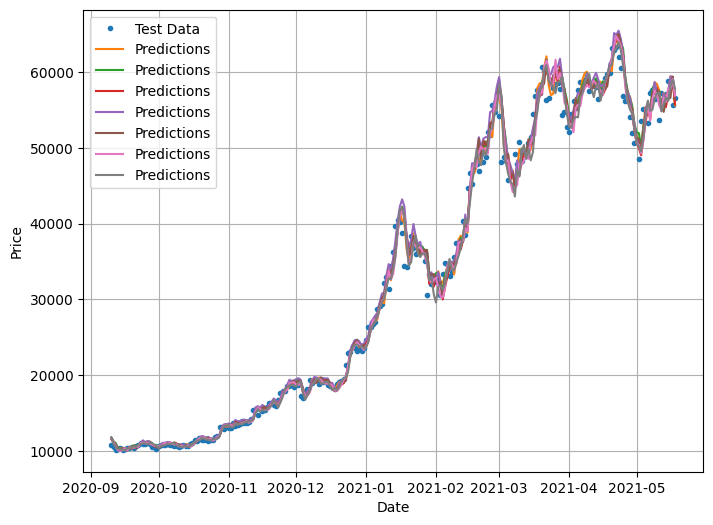

In [78]:
# Plotting Model Predictions:
offset= 300
plt.figure(figsize= (8,6))
plot_time_series(timesteps= X_test[-len(test_windows):], values= test_labels[:, 0], start= offset, labels= 'Test Data')
plot_time_series(timesteps= X_test[-len(test_windows):], values= model_3_preds, start= offset, format= '-', labels= 'Predictions')

When we try to plot our multi-horizon predicts, we get a funky looking plot.

Again, we can fix this by aggregating our model's predictions.

> 🔑 **Note:** Aggregating the predictions (e.g. reducing a 7-day horizon to one value such as the mean) loses information from the original prediction. As in, the model predictions were trained to be made for 7-days but by reducing them to one, we gain the ability to plot them visually but we lose the extra information contained across multiple days.

In [79]:
model_3_preds[0], model_3_preds[0].shape

(<tf.Tensor: shape=(7,), dtype=float32, numpy=
 array([9528.522, 9518.389, 9471.428, 9417.596, 9447.873, 9263.168,
        9407.272], dtype=float32)>,
 TensorShape([7]))

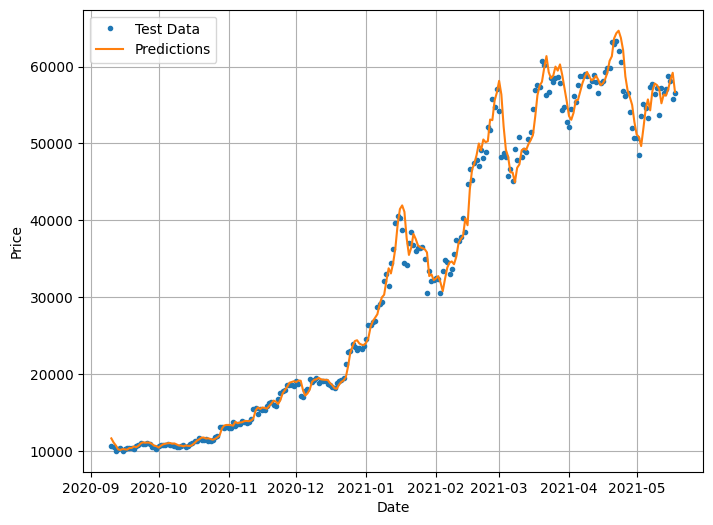

In [80]:
# Plotting Model Predictions:
offset= 300
plt.figure(figsize= (8,6))
plot_time_series(timesteps= X_test[-len(test_windows):], values= test_labels[:, 0], start= offset, labels= 'Test Data')
plot_time_series(timesteps= X_test[-len(test_windows):],
                 values= tf.reduce_mean(model_3_preds, axis= 1),
                 start= offset, format= '-', labels= 'Predictions')

## Which of our models is performing best so far?

So far, we've trained 3 models which use the same architecture but use different data inputs.

Let's compare them with the naïve model to see which model is performing the best so far.

<Axes: >

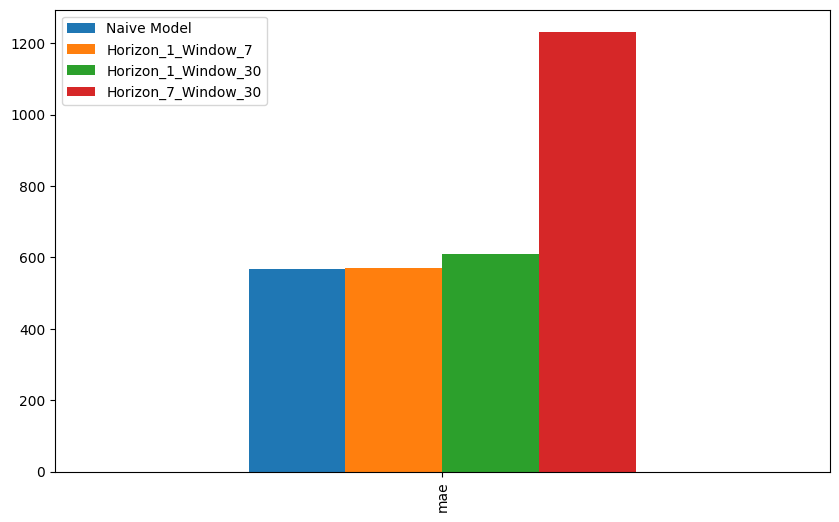

In [81]:
pd.DataFrame({'Naive Model': naive_results['mae'],
             'Horizon_1_Window_7': model_1_results['mae'],
             'Horizon_1_Window_30': model_2_results['mae'],
             'Horizon_7_Window_30': model_3_results['mae']},
             index= ['mae']).plot(kind= 'bar', figsize= (10,6))

Woah, our naïve model is performing best (it's very hard to beat a naïve model in open systems) but the dense model with a horizon of 1 and a window size of 7 looks to be performing cloest.

Because of this, let's use `HORIZON=1` and `WINDOW_SIZE=7` for our next series of modelling experiments (in other words, we'll use the previous week of Bitcoin prices to try and predict the next day).

> 🔑 **Note:** You might be wondering, why are the naïve results so good? One of the reasons could be due the presence of **autocorrelation** in the data. If a time series has **autocorrelation** it means the value at `t+1` (the next timestep) is typically close to the value at `t` (the current timestep). In other words, today's value is probably pretty close to yesterday's value. Of course, this isn't always the case but when it is, a naïve model will often get fairly good results.

> 📖 **Resource:** For more on how autocorrelation influences a model's predictions, see the article [*How (not) to use Machine Learning for time series forecasting: Avoiding the pitfalls*](https://towardsdatascience.com/how-not-to-use-machine-learning-for-time-series-forecasting-avoiding-the-pitfalls-19f9d7adf424) by Vegard Flovik